# Architecture of filters

So, the english is not very good, I will improve that

In [1]:
import itertools

import sympy as sy
import numpy as np

from sympy import Matrix
from scipy.linalg import circulant
from sympy.physics.quantum import TensorProduct
from sympy.matrices.dense import matrix_multiply_elementwise

In [2]:
import fitz

from lib.utils import plot_pdf, plot_pdf2col, symmetrical_cyclic_convolution, conv_circ_fft

In [3]:
from sympy import init_printing
# init_printing(use_latex='png', forecolor='White', backcolor='Black')

In [4]:
doc = fitz.open('Blahut_2010_Fast algorithms for signal processing.pdf')

The base for this tutorial is the book "Fast Algorithms or Signal Processing" of Blahut.

This tutorial not work with others vector sizes

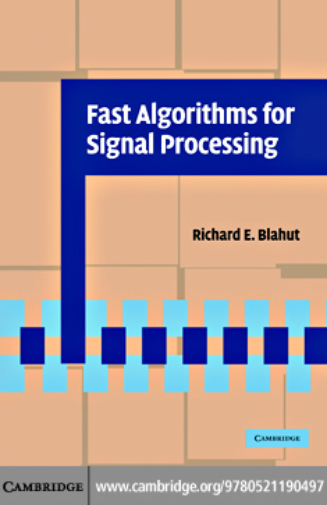

In [5]:
plot_pdf(doc[0], dpi=100)

## Polynomials

Size of vectors

In [21]:
d_num = 3
g_num = 3

In [22]:
b_degree = d_num + g_num - 1
b_degree

5

In [23]:
b0 = [0, -1, 1, -2, sy.oo]
# sy.Rational(1, 2)
sy.Matrix(b0)

Matrix([
[ 0],
[-1],
[ 1],
[-2],
[oo]])

Example of vectors for the convolution

In [24]:
d_values = list(range(1, d_num+1))
g_values = list(range(1, g_num+1))
print(d_values, g_values)

[1, 2, 3] [1, 2, 3]


Polynomial degree

In [25]:
d_degree = d_num - 1
g_degree = g_num - 1
print(d_degree, g_degree)

2 2


In [26]:
x = sy.symbols("x")
x

x

In [27]:
d0 = sy.Matrix(sy.symbols(" ".join(f"d_{i}"for i in range(d_num))))
d0

Matrix([
[d_0],
[d_1],
[d_2]])

In [28]:
g0 = sy.Matrix(sy.symbols(" ".join(f"g_{i}"for i in range(g_num))))
g0

Matrix([
[g_0],
[g_1],
[g_2]])

In [31]:
dx = sum([i*x**e for e, i in enumerate(d0)])
dx

d_0 + d_1*x + d_2*x**2

In [32]:
gx = sum([i*x**e for e, i in enumerate(g0)])
gx

g_0 + g_1*x + g_2*x**2

In [33]:
sx = gx*dx
sx

(d_0 + d_1*x + d_2*x**2)*(g_0 + g_1*x + g_2*x**2)

In [34]:
xi = [x**i for i in range(1, sy.degree(sx.expand(), x) + 1)]
xi

[x, x**2, x**3, x**4]

In [35]:
_a_mtx = [[(b **e) for e, d in enumerate(d0)] for b in b0 if b != sy.oo]
_a_inf = [[0] * (len(d0) - 1) + [1]]
a_mtx = sy.Matrix(_a_mtx + _a_inf)
a_mtx

Matrix([
[1,  0, 0],
[1, -1, 1],
[1,  1, 1],
[1, -2, 4],
[0,  0, 1]])

In [36]:
_b_mtx = [[(b **e) for e, d in enumerate(g0)] for b in b0 if b != sy.oo]
_b_inf = [[0] * (len(g0) - 1) + [1]]
b_mtx = sy.Matrix(_b_mtx + _b_inf)
b_mtx

Matrix([
[1,  0, 0],
[1, -1, 1],
[1,  1, 1],
[1, -2, 4],
[0,  0, 1]])

In [37]:
cd = [sy.expand(np.prod([(x - b) for b in i if b != sy.oo])) for i in itertools.combinations(reversed(b0), len(b0)-1)]
sy.Matrix(cd)

Matrix([
[     x**3 + 2*x**2 - x - 2],
[         x**3 + x**2 - 2*x],
[       x**3 + 3*x**2 + 2*x],
[                  x**3 - x],
[x**4 + 2*x**3 - x**2 - 2*x]])

In [38]:
b0_inf = [x for x in b0 if x != sy.oo]
b0_inf

[0, -1, 1, -2]

In [39]:
_cq = [
    1/sy.expand(np.prod([(b0 - b) for b in i]))
    for b0, i in 
    zip(b0_inf, itertools.combinations(reversed(b0_inf), len(b0_inf)-1))
]
cq = _cq + [1]
sy.Matrix(cq)

Matrix([
[-1/2],
[ 1/2],
[ 1/6],
[-1/6],
[   1]])

In [40]:
c0 = sy.Matrix([s.subs({x:0}) for s in cd])
c0.T

Matrix([[-2, 0, 0, 0, 0]])

In [41]:
c1 = sy.Matrix([[d.coeff(c, 1) for c in xi] for d in cd])
c1.T

Matrix([
[-1, -2, 2, -1, -2],
[ 2,  1, 3,  0, -1],
[ 1,  1, 1,  1,  2],
[ 0,  0, 0,  0,  1]])

In [42]:
c_mtx = sy.Matrix(c0.T.tolist() + c1.T.tolist())
c_mtx

Matrix([
[-2,  0, 0,  0,  0],
[-1, -2, 2, -1, -2],
[ 2,  1, 3,  0, -1],
[ 1,  1, 1,  1,  2],
[ 0,  0, 0,  0,  1]])

In [43]:
bg_mtx = sy.diag(*(sy.diag(*cq) * b_mtx * g0).tolist())
bg_mtx

Matrix([
[-g_0/2,                     0,                     0,                        0,   0],
[     0, g_0/2 - g_1/2 + g_2/2,                     0,                        0,   0],
[     0,                     0, g_0/6 + g_1/6 + g_2/6,                        0,   0],
[     0,                     0,                     0, -g_0/6 + g_1/3 - 2*g_2/3,   0],
[     0,                     0,                     0,                        0, g_2]])

In [44]:
s = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(d0))
s

Matrix([
[-2,  0, 0,  0,  0],
[-1, -2, 2, -1, -2],
[ 2,  1, 3,  0, -1],
[ 1,  1, 1,  1,  2],
[ 0,  0, 0,  0,  1]])*Matrix([
[-g_0/2,                     0,                     0,                        0,   0],
[     0, g_0/2 - g_1/2 + g_2/2,                     0,                        0,   0],
[     0,                     0, g_0/6 + g_1/6 + g_2/6,                        0,   0],
[     0,                     0,                     0, -g_0/6 + g_1/3 - 2*g_2/3,   0],
[     0,                     0,                     0,                        0, g_2]])*Matrix([
[1,  0, 0],
[1, -1, 1],
[1,  1, 1],
[1, -2, 4],
[0,  0, 1]])*Matrix([
[d_0],
[d_1],
[d_2]])

## Example

In [45]:
subs = {k[0]: v for k, v in zip(d0.tolist()+g0.tolist(), d_values + g_values)}
subs

{d_0: 1, d_1: 2, d_2: 3, g_0: 1, g_1: 2, g_2: 3}

In [46]:
si = s.subs(subs)
si

Matrix([
[-2,  0, 0,  0,  0],
[-1, -2, 2, -1, -2],
[ 2,  1, 3,  0, -1],
[ 1,  1, 1,  1,  2],
[ 0,  0, 0,  0,  1]])*Matrix([
[-1/2, 0, 0,    0, 0],
[   0, 1, 0,    0, 0],
[   0, 0, 1,    0, 0],
[   0, 0, 0, -3/2, 0],
[   0, 0, 0,    0, 3]])*Matrix([
[1,  0, 0],
[1, -1, 1],
[1,  1, 1],
[1, -2, 4],
[0,  0, 1]])*Matrix([
[1],
[2],
[3]])

In [47]:
sy.expand(sx)

d_0*g_0 + d_0*g_1*x + d_0*g_2*x**2 + d_1*g_0*x + d_1*g_1*x**2 + d_1*g_2*x**3 + d_2*g_0*x**2 + d_2*g_1*x**3 + d_2*g_2*x**4

Let's compare the output polynomial matrix from direct and winograd method

In [48]:
sy.Matrix(np.convolve(np.array(d0).reshape(-1), np.array(g0).reshape(-1)))

Matrix([
[                    d_0*g_0],
[          d_0*g_1 + d_1*g_0],
[d_0*g_2 + d_1*g_1 + d_2*g_0],
[          d_1*g_2 + d_2*g_1],
[                    d_2*g_2]])

In [49]:
se = sy.MatMul(c_mtx, bg_mtx, a_mtx, sy.Matrix(d0), evaluate=True)
se

Matrix([
[                    d_0*g_0],
[          d_0*g_1 + d_1*g_0],
[d_0*g_2 + d_1*g_1 + d_2*g_0],
[          d_1*g_2 + d_2*g_1],
[                    d_2*g_2]])

Comparing numerical outputs from direct and winograd method

In [50]:
sy.Matrix(np.convolve(d_values, g_values))

Matrix([
[ 1],
[ 4],
[10],
[12],
[ 9]])

In [51]:
se.subs(subs)

Matrix([
[ 1],
[ 4],
[10],
[12],
[ 9]])

In [75]:
ad0s = Matrix(sy.symbols(" ".join(f"D_{i}"for i in range(len(b0)))))
ad0

Matrix([
[D_0],
[D_1],
[D_2],
[D_3],
[D_4]])

In [76]:
bg0s = Matrix(sy.symbols(" ".join(f"G_{i}"for i in range(len(b0)))))
bg0s

Matrix([
[G_0],
[G_1],
[G_2],
[G_3],
[G_4]])

In [86]:
ss0s = Matrix(sy.symbols(" ".join(f"S_{i}"for i in range(len(b0)))))
ss0s

Matrix([
[S_0],
[S_1],
[S_2],
[S_3],
[S_4]])

In [87]:
s0s = Matrix(sy.symbols(" ".join(f"s_{i}"for i in range(len(b0)))))
s0s

Matrix([
[s_0],
[s_1],
[s_2],
[s_3],
[s_4]])

In [123]:
def step(ff0, mtx, f0):
    f1 = mtx * f0
    f2 = sy.Eq(ff0, sy.Eq(f1, sy.MatMul(mtx, f0, evaluate=False), evaluate=False), evaluate=False)
    return f2

In [131]:
bg1 = step(bg0s, b_mtx, g0)
bg1

Eq(Matrix([
[G_0],
[G_1],
[G_2],
[G_3],
[G_4]]), Eq(Matrix([
[                g_0],
[    g_0 - g_1 + g_2],
[    g_0 + g_1 + g_2],
[g_0 - 2*g_1 + 4*g_2],
[                g_2]]), Matrix([
[1,  0, 0],
[1, -1, 1],
[1,  1, 1],
[1, -2, 4],
[0,  0, 1]])*Matrix([
[g_0],
[g_1],
[g_2]])))

In [125]:
ad1 = step(ad0s, a_mtx, d0)
ad1

Eq(Matrix([
[D_0],
[D_1],
[D_2],
[D_3],
[D_4]]), Eq(Matrix([
[                d_0],
[    d_0 - d_1 + d_2],
[    d_0 + d_1 + d_2],
[d_0 - 2*d_1 + 4*d_2],
[                d_2]]), Matrix([
[1,  0, 0],
[1, -1, 1],
[1,  1, 1],
[1, -2, 4],
[0,  0, 1]])*Matrix([
[d_0],
[d_1],
[d_2]])))

In [89]:
ss1 = sy.Eq(ss0s, sy.diag(*bg0s)*ad0, evaluate=False)
ss1

Eq(Matrix([
[S_0],
[S_1],
[S_2],
[S_3],
[S_4]]), Matrix([
[D_0*G_0],
[D_1*G_1],
[D_2*G_2],
[D_3*G_3],
[D_4*G_4]]))

In [126]:
s1 = step(s0s, c_mtx, ss0s)
s1

Eq(Matrix([
[s_0],
[s_1],
[s_2],
[s_3],
[s_4]]), Eq(Matrix([
[                            -2*S_0],
[-S_0 - 2*S_1 + 2*S_2 - S_3 - 2*S_4],
[         2*S_0 + S_1 + 3*S_2 - S_4],
[     S_0 + S_1 + S_2 + S_3 + 2*S_4],
[                               S_4]]), Matrix([
[-2,  0, 0,  0,  0],
[-1, -2, 2, -1, -2],
[ 2,  1, 3,  0, -1],
[ 1,  1, 1,  1,  2],
[ 0,  0, 0,  0,  1]])*Matrix([
[S_0],
[S_1],
[S_2],
[S_3],
[S_4]])))